In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import clear_output
import openmm
from openmm import unit
kB = unit.MOLAR_GAS_CONSTANT_R.value_in_unit(unit.kilojoule_per_mole/unit.kelvin)
import bgflow as bg
ctx = {'dtype': torch.float32, 'device': torch.device('cpu') if torch.cuda.is_available() else torch.device('cpu')}
from DoubleWell import *

In [ ]:
dim = base_dim = 2**1
T_high = 600
modelMD = DoubleWellOpenMM(ModifiedWolfeQuapp(base_dim))
modelMD.dim, modelMD.MD_dim

(2, 3)

In [9]:
%%time
n_frames = 10000        
total_time_ns = 20    
dt_ps = 0.0005            

total_steps = int((total_time_ns * 1000) / dt_ps)
pace = int(total_steps // n_frames)

print(f"--- Simulation Setup ---")
print(f"Target Frames : {n_frames}")
print(f"Total Time    : {total_time_ns} ns")
print(f"Step Pace     : {pace} steps/frame")
print(f"Check         : Saving every {pace * dt_ps:.3f} ps")
print(f"------------------------")

try:
    loaded = np.load(f'dw_T600_{total_time_ns}ns.npz')
    data = loaded['positions']
    time_labels = loaded['time']
    print(f"Loaded existing data for {total_time_ns}ns.")
except:
    n_equil = 1000
    integrator = openmm.LangevinMiddleIntegrator(600*unit.kelvin, 10./unit.picosecond, dt_ps*unit.picosecond)
    simulation = openmm.app.Simulation(modelMD.topology, modelMD.system, integrator)
    simulation.context.setPositions(modelMD.positions)
    simulation.step(n_equil)

    data = np.full((n_frames, *modelMD.positions.shape), np.nan)
    time_labels = np.zeros(n_frames) # <--- 新增：用来存时间标签的数组

    print("Start Sampling...")
    for n in range(n_frames):
        simulation.step(pace)
        
        pos = simulation.context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(unit.nanometers)
        data[n] = pos
        
        current_time = (n + 1) * pace * dt_ps / 1000.0 
        time_labels[n] = current_time

        if (n+1) % (n_frames // 20) == 0:
            clear_output(wait=True)
            try:
                plot_doublewell(data[:n+1]) 
            except:
                pass
            
            print(f'Progress: {(n+1)/n_frames:.1%} | Current Time: {current_time:.2f} / {total_time_ns} ns')

    save_name = f'dw_T600_{total_time_ns}ns.npz'
    np.savez(save_name, positions=data, time=time_labels)
    print(f"\nSaved data and time labels to {save_name}")

MDdata = data
target_data = torch.tensor(MDdata.reshape(len(MDdata), -1)[:,:2]).float().to(**ctx)


--- Simulation Setup ---
Target Frames : 10000
Total Time    : 20 ns
Step Pace     : 4000 steps/frame
Check         : Saving every 2.000 ps
------------------------
Loaded existing data for 20ns.
CPU times: user 3.33 ms, sys: 17 µs, total: 3.35 ms
Wall time: 2.64 ms


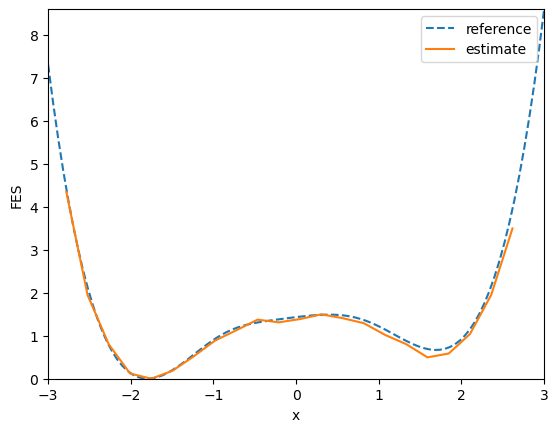

ref DeltaF: 0.529608 [kBT]
    DeltaF: 0.393396 [kBT]


In [10]:
plot_fes(target_data[:,0], T_high)

In [ ]:
# define some plotting functions

from bgflow.utils.types import assert_numpy
from matplotlib.colors import ListedColormap

original_hsv = plt.cm.get_cmap('hsv')

half_hsv = ListedColormap(original_hsv(np.linspace(0, 0.7, 256)))
custom_cmap = half_hsv

def plot_energy(energy, extent=(-2.5, 2.5), resolution=100, dim=2):
    """ Plot energy functions in 2D """
    xs = torch.meshgrid([torch.linspace(*extent, resolution) for _ in range(2)])
    xs = torch.stack(xs, dim=-1).view(-1, 2)
    xs = torch.cat([
        xs,
        torch.Tensor(xs.shape[0], dim - xs.shape[-1]).zero_()
    ], dim=-1)
    us = energy.energy(xs).view(resolution, resolution)
    us = torch.exp(-us)
    plt.imshow(assert_numpy(us).T, extent=extent * 2)
    plt.xlim=(extent[0], extent[1])
    plt.ylim=(extent[0], extent[1])




def plot_samples(samples, weights=None, range=None, cmap=custom_cmap):
    """ Plot sample histogram in 2D """
    samples = assert_numpy(samples)
    plt.hist2d(
        samples[:, 0], 
        -samples[:, 1],
        weights=assert_numpy(weights) if weights is not None else weights,
        bins=100,
        norm=mpl.colors.LogNorm(),
        range=range, cmap=cmap
    )
    
def plot_bg(bg, target, n_samples=500000, target_samples=target_data, range=[-3, 3], dim=2):
    """ Plot target energy, bg energy and bg sample histogram"""
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 4, 1)
    plot_energy(target, extent=range, dim=dim)
    plt.title("Target energy")
    plt.subplot(1, 4, 2)
    plot_energy(bg, extent=range, dim=dim)
    plt.title("BG energy")
    plt.subplot(1, 4, 3)
    plot_samples(bg.sample(n_samples), range=[range, range])
    plt.title("BG samples")
    plt.subplot(1, 4, 4)
    plot_samples(target_samples, range=[range, range])
    plt.title("target samples")

def plot_weighted_energy_estimate(bg, target, n_samples=100000, extent=None, n_bins=100, range=[-2, 2], dim=dim):
    """ Plot weighed energy from samples """
    samples, latent, dlogp = bg.sample(n_samples, with_latent=True, with_dlogp=True)
    log_weights = bg.log_weights_given_latent(samples, latent, dlogp)

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    _, bins, _ = plt.hist(assert_numpy(samples[:, 0]), histtype="step", log=True, bins=n_bins, weights=None, density=True, label="samples", range=range)
    xs = torch.linspace(*range, n_bins).view(-1, 1)
    xs = torch.cat([xs, torch.zeros(xs.shape[0], dim - 1)], dim=-1).view(-1, dim)
    us = target.energy(xs).view(-1)
    us = torch.exp(-us)
    us = us / torch.sum(us * (bins[-1] - bins[0]) / n_bins)
    plt.plot(xs[:, 0], us, label="$\log p(x)$")
    plt.xlabel("$x0$")
    plt.ylabel("log density")
    plt.legend()
    plt.title("unweighed energy")
    
    plt.subplot(1, 3, 2)
    _, bins, _ = plt.hist(assert_numpy(samples[:, 0]), histtype="step", log=True, bins=n_bins, weights=assert_numpy(log_weights.exp()), density=True, label="samples", range=range)
    plt.plot(xs[:, 0], us, label="$\log p(x)$")
    plt.xlabel("$x0$")
    plt.legend()
    plt.title("weighed energy")

    plt.subplot(1, 3, 3)
    plt.xlabel("$x0$")
    plt.ylabel("$x1$")
    plot_samples(samples, weights=log_weights.exp(), range=[range, range])
    plt.title("weighed samples")



/tmp/ipykernel_3542855/3744750471.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  original_hsv = plt.cm.get_cmap('hsv')


# GF

In [14]:
MDdata[:,0,0].shape

(10000,)

In [15]:
# now set up a prior
from bgflow import NormalDistribution
prior = NormalDistribution(dim).to(**ctx)

In [16]:
# setup flow
store_energies = False
model = ModifiedWolfeQuapp(dim)
target = ModifiedWolfeQuapp(dim, beta=1/(T_high*kB)).to(**ctx)

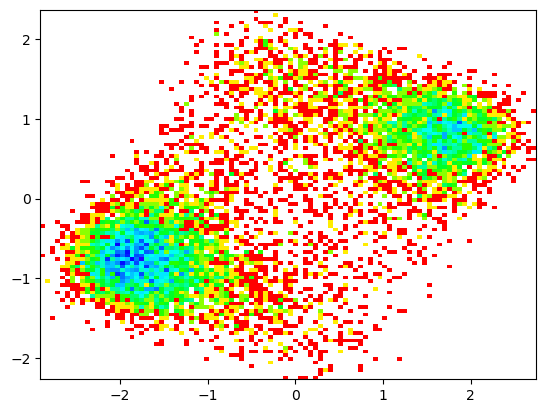

In [17]:
# data = data[:,2:]
plot_samples(MDdata.reshape(len(MDdata), -1)[:,:])

In [18]:
# define a flow with RNVP coupling layers

from bgflow.nn import (
    DenseNet,
    SequentialFlow, 
    CouplingFlow, 
    AffineFlow, 
    SplitFlow, 
    InverseFlow, 
    SwapFlow,
    AffineTransformer
)



# here we aggregate all layers of the flow
layers = []

# start with a splitting layer which splits the input tensor into two 
# flow channels with tensors of half dimensionality
layers.append(SplitFlow(dim // 2))


# now add coupling layers
n_coupling_layers = 4
for _ in range(n_coupling_layers):
    
    # we need to swap dimensions for the mixing
    layers.append(SwapFlow())
    
    # now set up a coupling block
    layers.append(CouplingFlow(
        # we use a affine transformation to transform the RHS conditioned on the LHS
        AffineTransformer(
            # use simple dense nets for the affine shift/scale
            shift_transformation=DenseNet([dim // 2, 64, 64, dim // 2], activation=torch.nn.ReLU()), 
            scale_transformation=DenseNet([dim // 2, 64, 64, dim // 2], activation=torch.nn.ReLU())
        )
    ))
    
# finally, we have to merge the two channels again into one tensor
layers.append(InverseFlow(SplitFlow(dim // 2)))
    
# now define the flow as a sequence of all operations stored in layers
flow = SequentialFlow(layers)

In [19]:
from bgflow import BoltzmannGenerator

bg = BoltzmannGenerator(prior, flow, target).to(**ctx)

/home/dell/software/miniforge3/envs/bgflow/lib/python3.8/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1724571756729/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


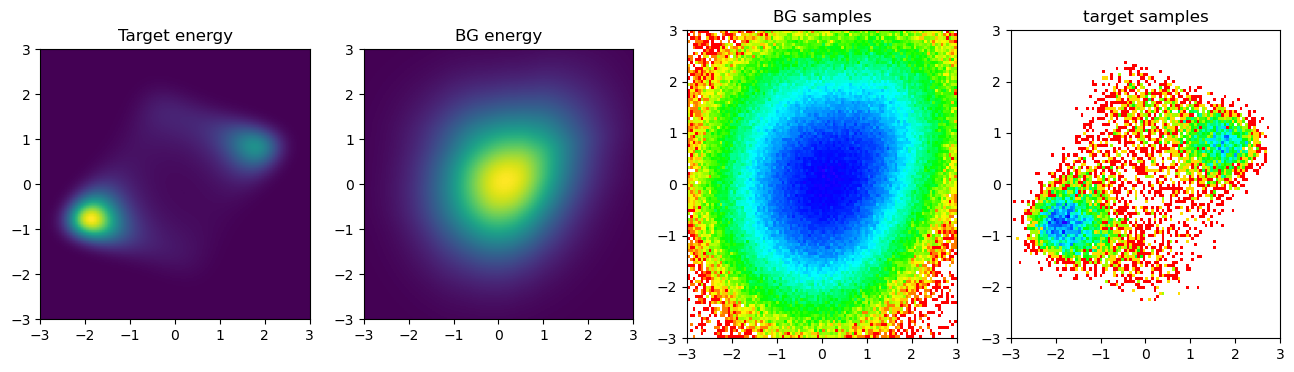

In [20]:
plot_bg(bg, target, dim=dim)

In [21]:
from bgflow.utils.types import is_list_or_tuple

class LossReporter:
    """
        Simple reporter use for reporting losses and plotting them.
    """
    
    def __init__(self, *labels):
        self._labels = labels
        self._n_reported = len(labels)
        self._raw = [[] for _ in range(self._n_reported)]
    
    def report(self, *losses):
        assert len(losses) == self._n_reported
        for i in range(self._n_reported):
            self._raw[i].append(assert_numpy(losses[i]))
    
    def plot(self, n_smooth=10):
        fig, axes = plt.subplots(self._n_reported, sharex=True)
        if not isinstance(axes, np.ndarray):
            axes = [axes]
        fig.set_size_inches((8, 4 * self._n_reported), forward=True)
        for i, (label, raw, axis) in enumerate(zip(self._labels, self._raw, axes)):
            raw = assert_numpy(raw).reshape(-1)
            kernel = np.ones(shape=(n_smooth,)) / n_smooth
            smoothed = np.convolve(raw, kernel, mode="valid")
            axis.plot(smoothed)
            axis.set_ylabel(label)
            if i == self._n_reported - 1:
                axis.set_xlabel("Iteration")
                
    def recent(self, n_recent=1):
        return np.array([raw[-n_recent:] for raw in self._raw])

In [22]:
# initial training with likelihood maximization on data set

from bgflow.utils.train import IndexBatchIterator

n_batch = 32
batch_iter = IndexBatchIterator(len(target_data), n_batch)

optim = torch.optim.Adam(bg.parameters(), lr=1e-3)

n_epochs =5
n_report_steps = 50

reporter = LossReporter("NLL")

---------epoch: 0---------

epoch: 0, iter: 300/312, NLL: 2.562---------epoch: 1---------

epoch: 1, iter: 300/312, NLL: 2.226---------epoch: 2---------

epoch: 2, iter: 300/312, NLL: 2.179---------epoch: 3---------

epoch: 3, iter: 300/312, NLL: 2.436---------epoch: 4---------

epoch: 4, iter: 300/312, NLL: 2.102

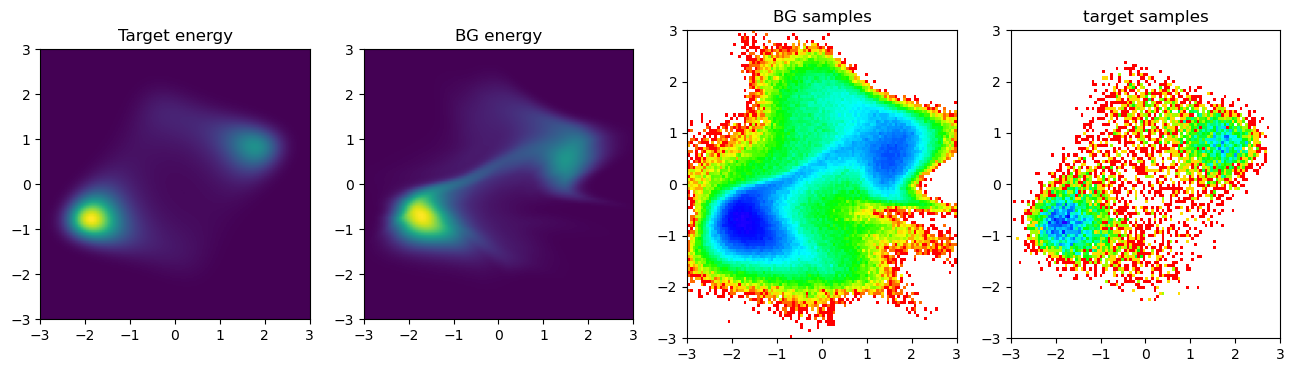

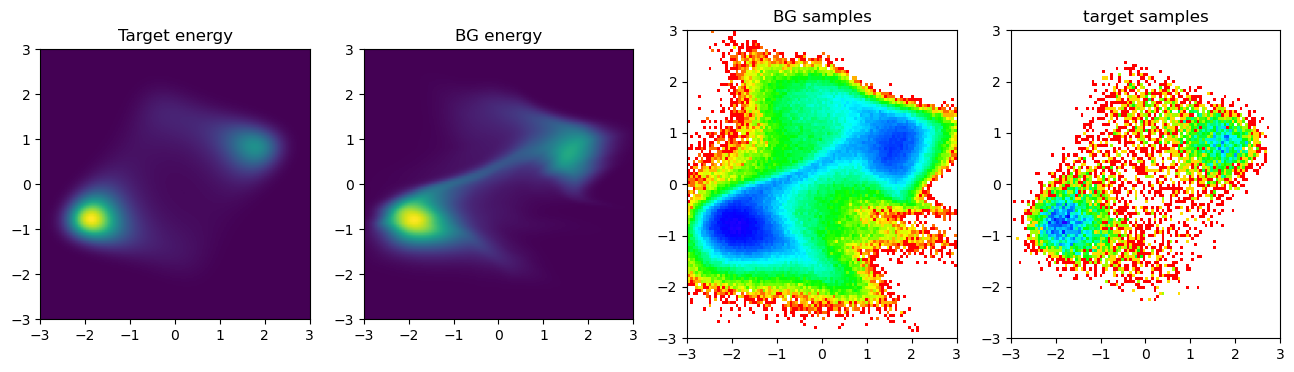

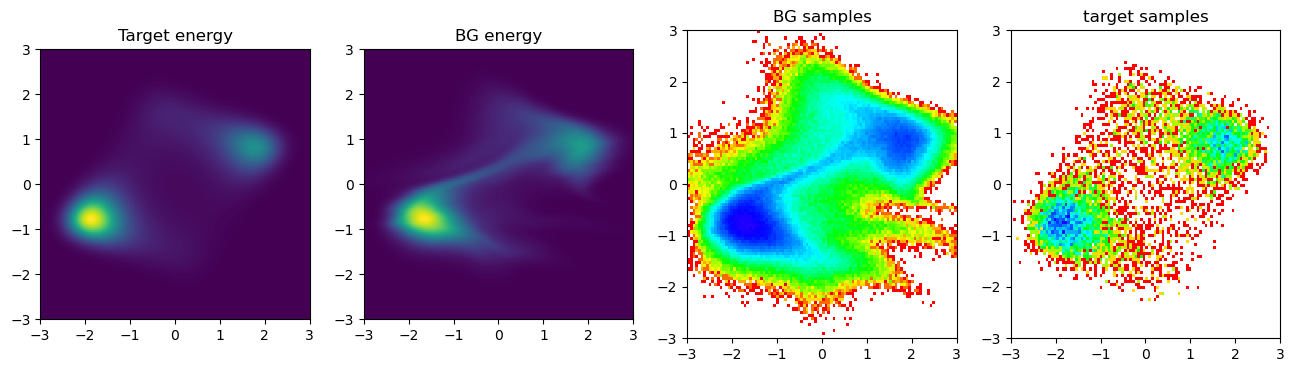

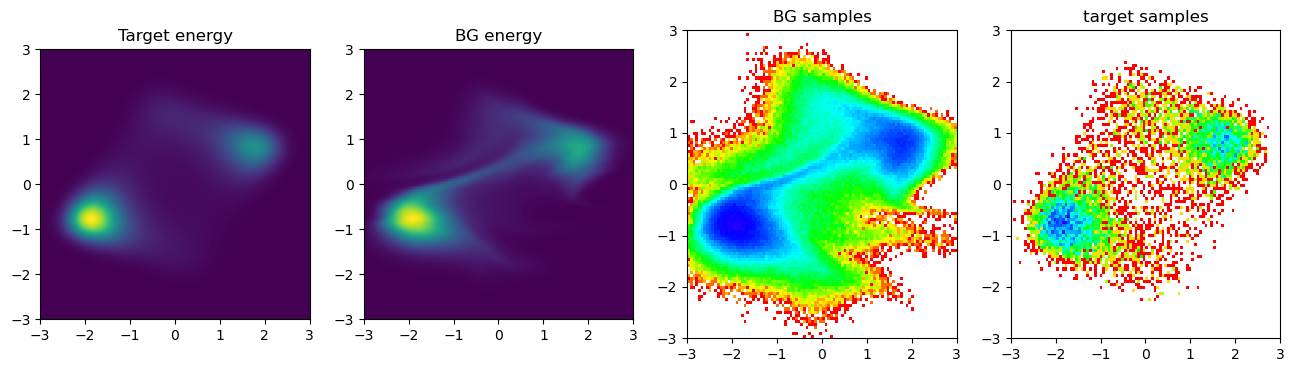

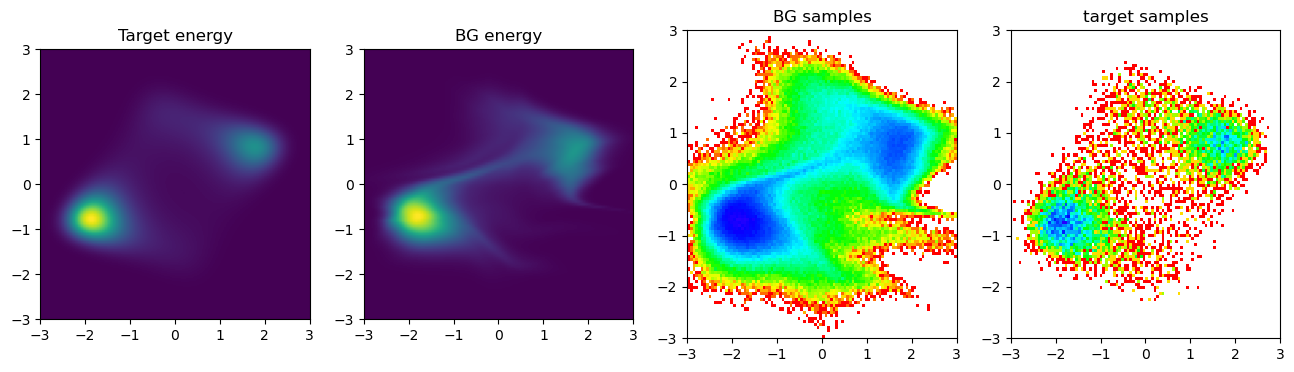

In [23]:
for epoch in range(n_epochs):
    print(f'---------epoch: {epoch}---------\n')
    for it, idxs in enumerate(batch_iter):
        batch = target_data[idxs]
        
        optim.zero_grad()
        
        # negative log-likelihood of the batch is equal to the energy of the BG
        nll = bg.energy(batch).mean()
        nll.backward()
        
        reporter.report(nll)
        
        optim.step()
        
        if it % n_report_steps == 0:
            print("\repoch: {0}, iter: {1}/{2}, NLL: {3:.4}".format(
                    epoch,
                    it,
                    len(batch_iter),
                    *reporter.recent(1).ravel()
                ), end="")
    plot_bg(bg, target, dim=dim)
    

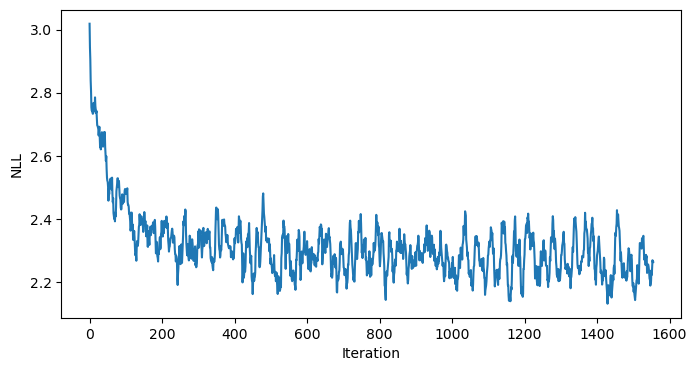

In [24]:
reporter.plot()

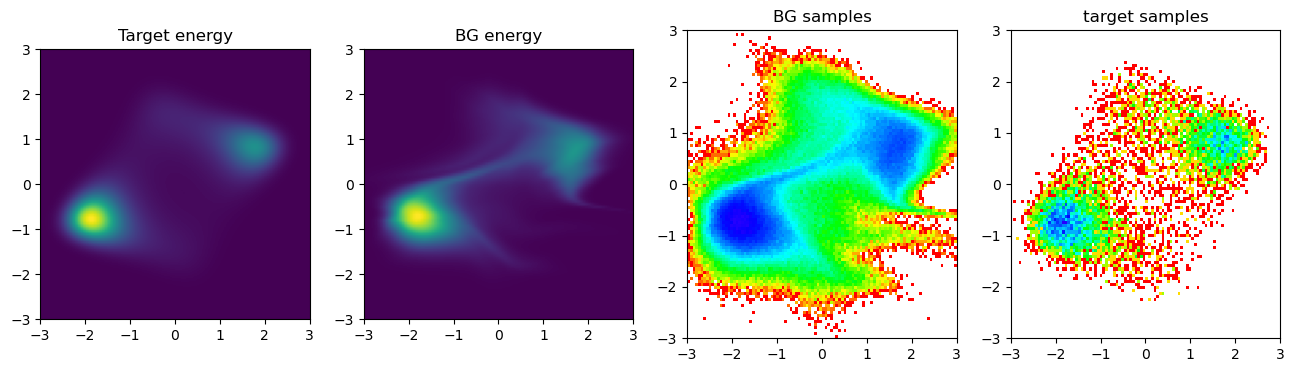

In [25]:
plot_bg(bg, target, dim=dim)
# plot_weighted_energy_estimate(bg, target, dim=dim)

In [ ]:
# torch.save(bg.state_dict(), f"models/GF_dw_dim2_T600.pth")
# data = bg.sample(500000).detach().numpy()